# Ridge regression

la regresion ridge es una regression lineal el cual trata de agregar una penalizacion de tipo L2
esta se garantiza por suavizar los posibles valores que generen ruido en una regression.

imaginemos el caso en e cual las features tengan una relacion entre si como seria el
precio de una casa dado el lugar donde vive y el numero de cuartos en ella, para este caso la relacion que tiene las caracteristicas entre si es demasido grande., por lo cual se tiene que agregar una penalizacion para que 
esta relacion no afecte mucho a la predicion

## Ridge manual

[-0.63728538  1.1336803 ]
[0.0989886  0.78844831]


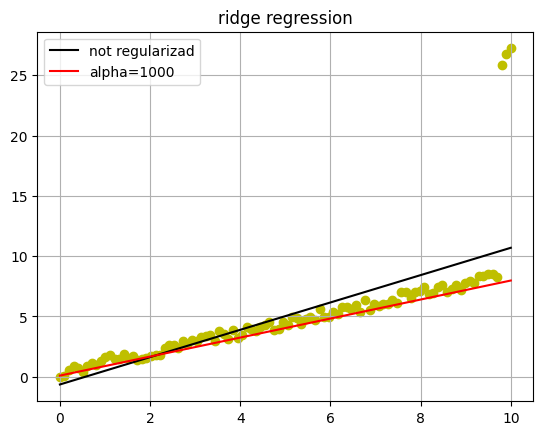

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N = 100 
X = np.linspace(0,10,N)
y = 0.8*X + np.random.random(N)

for i in range(1,4):
    y[-i]+=20-i


X = np.vstack([np.ones(N), X]).T

for alpha,color, label in zip([0,1000],['k','red'],['not regularizad','alpha=1000']):
    w = np.linalg.pinv((X.T@X+alpha*np.eye(2)))@X.T@y
    y_result = X@w
    plt.plot(X[:,1],y_result,color=color,label=label)
    print(w)


plt.scatter(X[:,1],y, color='y')
plt.title('ridge regression')
plt.legend(); plt.grid()
plt.show()

# Ridge con scikit

slopes: [5.30008833], intercepto:-10.445631653368036


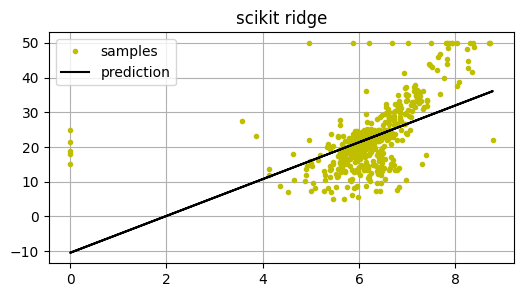

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
import numpy as np

dataSetBoston = pd.read_csv('../Data_sets/BostonHousing.csv')


def plot(data2D, target1D, predict1D):
    plt.figure(figsize=(6, 3))
    plt.plot(data2D,target1D, 'y.', markersize=6,label='samples')
    plt.plot(data2D,predict1D, 'k-', label='prediction')
    plt.legend()
    plt.title('scikit ridge')
    plt.grid()
    plt.show()
    return

dataSetBoston['rm'] = dataSetBoston['rm'].map(lambda x: x if str(x) != 'nan' else 0.0)

X = np.array(dataSetBoston['rm'])
X = X[:,np.newaxis]

y = dataSetBoston['medv']


ridge = linear_model.Ridge(alpha=0.3)
ridge.fit(X,y)
print("slopes: " + str(ridge.coef_) + ", intercepto:"+ str(ridge.intercept_))

y_pred = ridge.predict(X)

plot(X,y,y_pred)